# Laboratorio 4 — Cuaderno 7: Preparacion de datos para Machine Learning

**Ejercicio 1.** Construccion del conjunto de datos para modelos de aprendizaje automatico.

Este cuaderno cubre todos los incisos del Ejercicio 1 de la Parte 2:
- 1.1-1.2: Construccion del dataset con coordenadas, bandas, indices y clorofila
- 1.3: Eliminacion de observaciones invalidas
- 1.4: Reporte de observaciones, variables y valores faltantes
- 1.5: Analisis exploratorio de variables
- 1.6: Justificacion de decisiones

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, datos
from src import indices as ix

print("Cargando dataset ML...")
dataset = datos.construir_dataset_ml()
print(f"Dataset cargado: {len(dataset):,} observaciones")

Cargando dataset ML...


Dataset cargado: 3,759,121 observaciones


## 1.1-1.2 Construccion del dataset

El dataset se construye a partir de los 22 GeoTIFFs descargados (11 fechas por lago). Cada fila representa un **pixel de agua valida** dentro de alguno de los lagos.

**Variables incluidas:**

| Variable | Descripcion | Tipo |
|----------|-------------|------|
| `x`, `y` | Coordenadas en UTM zona 15N (EPSG:32615) | float64 |
| `lago` | "Atitlan" o "Amatitlan" | object |
| `fecha` | Fecha de adquisicion | datetime |
| `B02` - `B10` | Reflectancia de 10 bandas espectrales (0-1) | float32 |
| `ndvi` | Normalized Difference Vegetation Index | float32 |
| `ndwi` | Normalized Difference Water Index | float32 |
| `ndci` | Normalized Difference Chlorophyll Index | float32 |
| `fai` | Floating Algae Index | float32 |
| `chl` | Clorofila-a en ug/L (variable respuesta) | float32 |

**Bandas espectrales:**
- B02: Azul (490 nm)
- B03: Verde (560 nm)
- B04: Rojo (665 nm)
- B05: Borde rojo (705 nm)
- B07: NIR2 (783 nm)
- B08: NIR (842 nm)
- B8A: NIR estrecho (865 nm)
- B11: SWIR1 (1610 nm)
- B12: SWIR2 (2190 nm)
- B10: Cirrus (1375 nm) — usada para deteccion de nubes

In [2]:
print("Columnas del dataset:")
print(list(dataset.columns))
print(f"\nDimension: {dataset.shape[0]:,} filas x {dataset.shape[1]} columnas")

Columnas del dataset:
['x', 'y', 'lago', 'fecha', 'B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'B10', 'ndvi', 'ndwi', 'ndci', 'fai', 'chl']

Dimension: 3,759,121 filas x 19 columnas


## 1.3 Eliminacion de observaciones invalidas

Los filtros aplicados durante la construccion del dataset eliminan:

1. **Pixeles fuera del lago:** La mascara de agua (`mascara_agua()`) combina 6 criterios (MNDWI, NDWI, AWEI, etc.) para identificar solo pixeles de superficie de agua.

2. **Valores NoData:** Los pixeles con valor `-32768` (valor de relleno de openEO) se convierten a NaN y se descartan.

3. **Nubes:** Se descartan pixeles con:
   - Cirrus: B10 > 0.01 (nube alta detectada por vapor de agua)
   - Nube densa: B02 > 0.28 Y B03 > 0.28 (brillo simultaneo en azul y verde)

4. **Senal insuficiente:** Pixeles donde B04 < 0.005 o B05 < 0.005 (reflectancia muy baja en rojo o borde rojo, donde el NDCI no es confiable).

El resultado es la mascara `agua_valida` que se aplica en `construir_dataset_ml()`.

In [3]:
print("=" * 60)
print("RESUMEN DE OBSERVACIONES")
print("=" * 60)
print(f"\nTotal de observaciones: {len(dataset):,}")
print(f"\nPor lago:")
print(dataset['lago'].value_counts())
print(f"\nPor fecha:")
print(dataset['fecha'].value_counts().sort_index())

RESUMEN DE OBSERVACIONES

Total de observaciones: 3,759,121

Por lago:
lago
Atitlan      3358365
Amatitlan     400756
Name: count, dtype: int64

Por fecha:


fecha
2025-01-18    309109
2025-01-28     36652
2025-04-13    305327
2025-04-15     36295
2025-04-28     36289
2025-05-13    305289
2025-07-17    298702
2025-11-21    306436
2025-11-24     36475
2025-12-29    308505
2026-01-08     36772
2026-02-02     36231
2026-02-07     36667
2026-02-12    306184
2026-03-24    305417
2026-03-29     36703
2026-04-13    341559
2026-04-28    339660
2026-06-19     36742
2026-07-22    304107
Name: count, dtype: int64


In [4]:
print("\nObservaciones por lago y fecha:")
tabla_cruzada = dataset.groupby(['lago', 'fecha']).size().unstack(fill_value=0)
tabla_cruzada.columns = tabla_cruzada.columns.strftime('%Y-%m-%d')
print(tabla_cruzada)


Observaciones por lago y fecha:


fecha      2025-01-18  2025-01-28  2025-04-13  2025-04-15  2025-04-28  \
lago                                                                    
Amatitlan           0       36652           0       36295       36289   
Atitlan        309109           0      305327           0           0   

fecha      2025-05-13  2025-07-17  2025-11-21  2025-11-24  2025-12-29  \
lago                                                                    
Amatitlan           0           0           0       36475           0   
Atitlan        305289      298702      306436           0      308505   

fecha      2026-01-08  2026-02-02  2026-02-07  2026-02-12  2026-03-24  \
lago                                                                    
Amatitlan       36772       36231       36667           0           0   
Atitlan             0           0           0      306184      305417   

fecha      2026-03-29  2026-04-13  2026-04-28  2026-06-19  2026-07-22  
lago                                             

## 1.4 Reporte de variables y valores faltantes

In [5]:
print("=" * 60)
print("TIPOS DE VARIABLES")
print("=" * 60)
print(dataset.dtypes)

TIPOS DE VARIABLES
x               float64
y               float64
lago             object
fecha    datetime64[ms]
B02             float32
B03             float32
B04             float32
B05             float32
B07             float32
B08             float32
B8A             float32
B11             float32
B12             float32
B10             float32
ndvi            float32
ndwi            float32
ndci            float32
fai             float32
chl             float32
dtype: object


In [6]:
print("\n" + "=" * 60)
print("VALORES FALTANTES")
print("=" * 60)
faltantes = dataset.isna().sum()
pct_faltantes = (faltantes / len(dataset) * 100).round(4)
reporte_faltantes = pd.DataFrame({
    'faltantes': faltantes,
    'porcentaje': pct_faltantes
})
print(reporte_faltantes[reporte_faltantes['faltantes'] > 0])
if reporte_faltantes['faltantes'].sum() == 0:
    print("No hay valores faltantes en el dataset.")


VALORES FALTANTES
Empty DataFrame
Columns: [faltantes, porcentaje]
Index: []
No hay valores faltantes en el dataset.


In [7]:
print("\n" + "=" * 60)
print("ESTADISTICAS DESCRIPTIVAS")
print("=" * 60)
print(dataset.describe())


ESTADISTICAS DESCRIPTIVAS


                  x             y                       fecha           B02  \
count  3.759121e+06  3.759121e+06                     3759121  3.759121e+06   
mean   7.016660e+05  1.622697e+06  2025-11-17 02:05:28.739000  7.926391e-02   
min    6.805100e+05  1.594630e+06         2025-01-18 00:00:00  5.490000e-02   
25%    6.910300e+05  1.622890e+06         2025-05-13 00:00:00  7.330000e-02   
50%    6.953100e+05  1.625230e+06         2025-12-29 00:00:00  7.810000e-02   
75%    6.997300e+05  1.627270e+06         2026-04-13 00:00:00  8.330000e-02   
max    7.681700e+05  1.631570e+06         2026-07-22 00:00:00  3.619000e-01   
std    2.139111e+04  8.428169e+03                         NaN  7.813472e-03   

                B03           B04           B05           B07           B08  \
count  3.759121e+06  3.759121e+06  3.759121e+06  3.759121e+06  3.759121e+06   
mean   5.323370e-02  2.979355e-02  2.776031e-02  2.464864e-02  2.097789e-02   
min    3.270000e-02  1.330000e-02  1.080000e-02 -4.

## 1.5 Analisis exploratorio de variables

A continuacion se presentan distribuciones, boxplots y correlaciones de las variables clave.

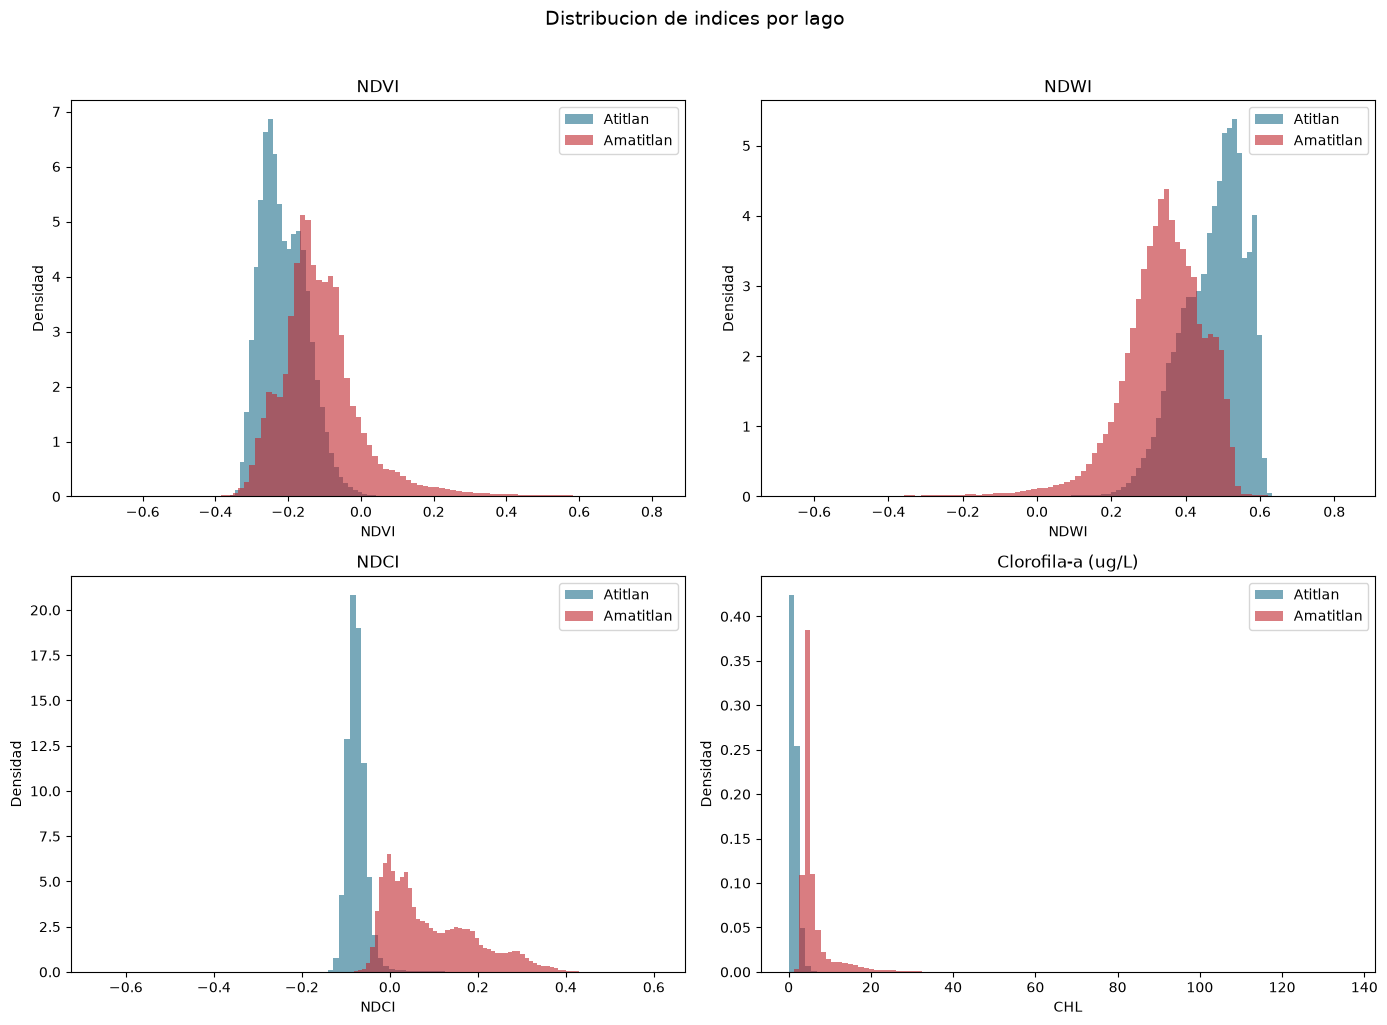

In [8]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

for ax, var, titulo in zip(
    ejes.ravel(),
    ['ndvi', 'ndwi', 'ndci', 'chl'],
    ['NDVI', 'NDWI', 'NDCI', 'Clorofila-a (ug/L)']
):
    for lago, color, alpha in [('Atitlan', '#1f6f8b', 0.6), ('Amatitlan', '#c1272d', 0.6)]:
        datos_lago = dataset[dataset['lago'] == lago][var]
        ax.hist(datos_lago, bins=100, alpha=alpha, color=color, label=lago, density=True)
    ax.set_title(titulo)
    ax.set_xlabel(var.upper())
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Distribucion de indices por lago', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

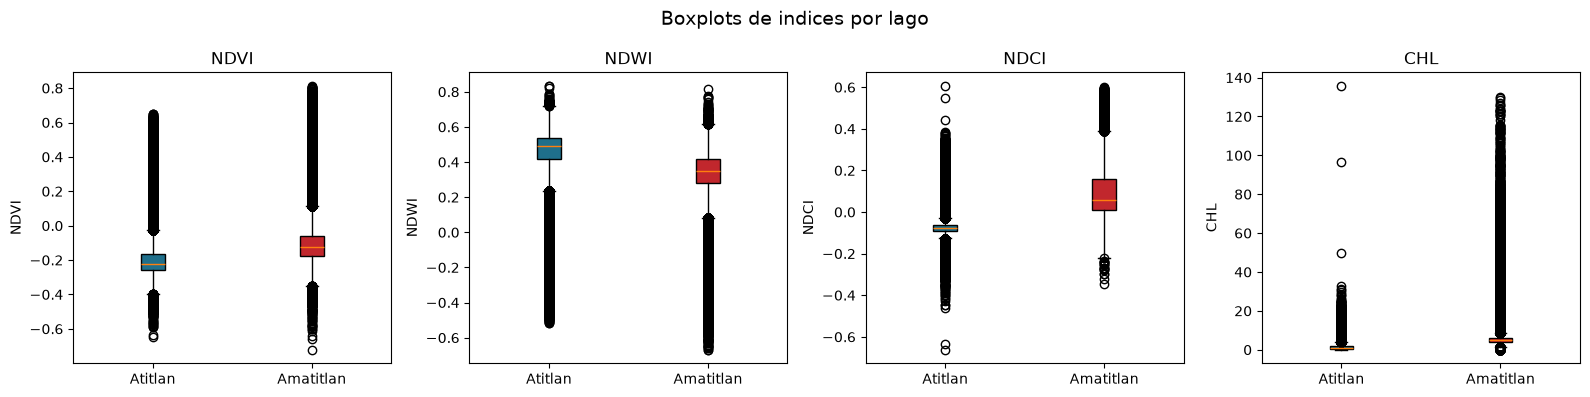

In [9]:
fig, ejes = plt.subplots(1, 4, figsize=(16, 4))

for ax, var in zip(ejes, ['ndvi', 'ndwi', 'ndci', 'chl']):
    datos_box = [dataset[dataset['lago'] == lago][var].values for lago in ['Atitlan', 'Amatitlan']]
    bp = ax.boxplot(datos_box, tick_labels=['Atitlan', 'Amatitlan'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#1f6f8b')
    bp['boxes'][1].set_facecolor('#c1272d')
    ax.set_title(var.upper())
    ax.set_ylabel(var.upper())

plt.suptitle('Boxplots de indices por lago', fontsize=14)
plt.tight_layout()
plt.show()

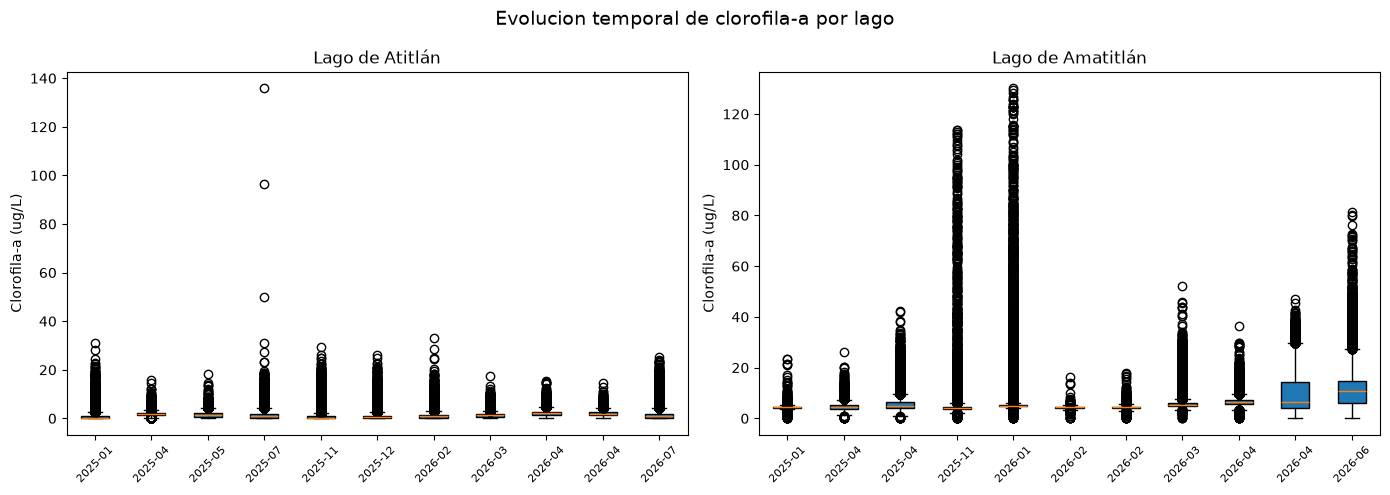

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

for i, lago in enumerate(['Atitlan', 'Amatitlan']):
    datos_lago = dataset[dataset['lago'] == lago]
    fechas_unicas = datos_lago['fecha'].dt.date.unique()
    fechas_ordenadas = sorted(fechas_unicas)
    
    datos_box = [datos_lago[datos_lago['fecha'].dt.date == f]['chl'].values for f in fechas_ordenadas]
    ejes[i].boxplot(datos_box, patch_artist=True)
    ejes[i].set_title(f'{config.NOMBRE_LARGO[lago]}')
    ejes[i].set_ylabel('Clorofila-a (ug/L)')
    ejes[i].tick_params(axis='x', rotation=45)
    ejes[i].set_xticklabels([f.strftime('%Y-%m') for f in fechas_ordenadas], fontsize=8)

plt.suptitle('Evolucion temporal de clorofila-a por lago', fontsize=14)
plt.tight_layout()
plt.show()

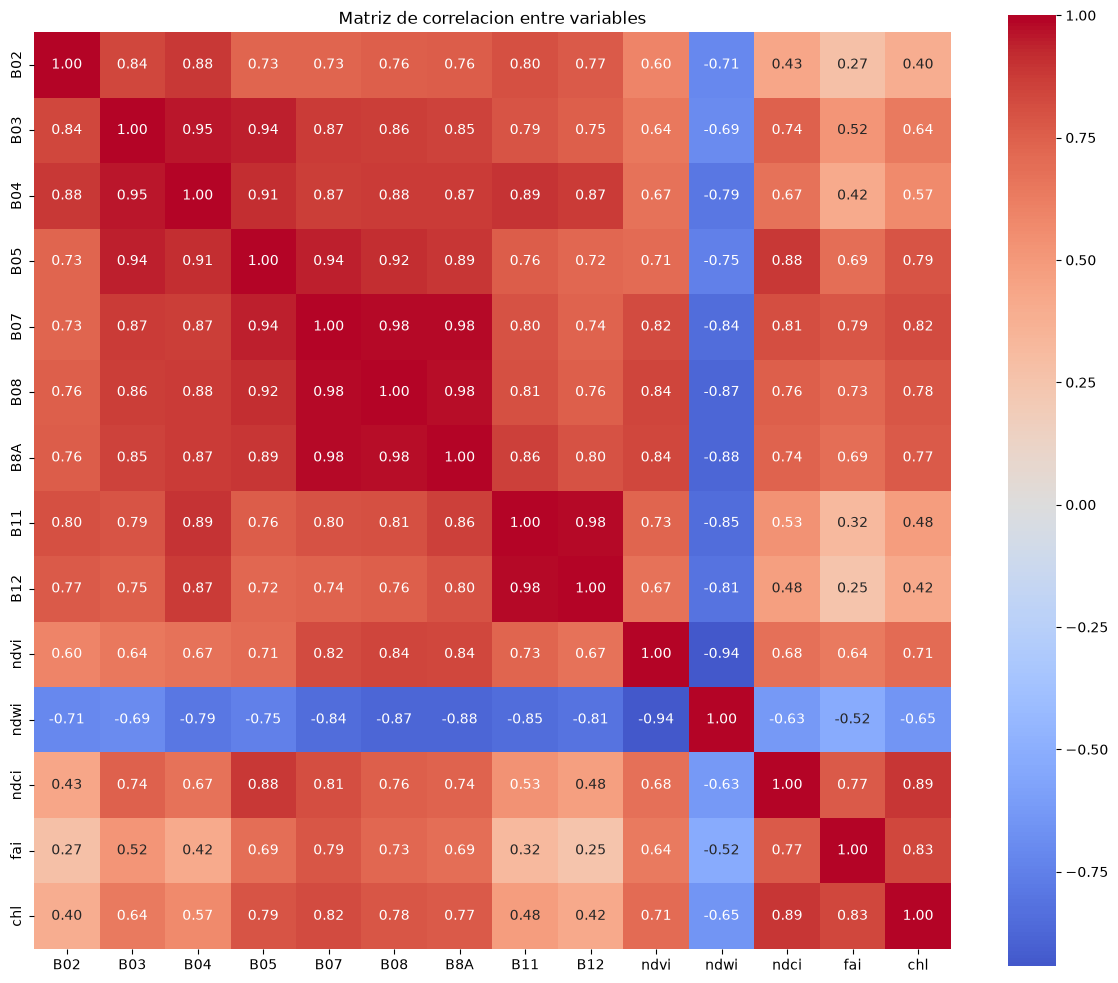

In [11]:
columnas_corr = ['B02', 'B03', 'B04', 'B05', 'B07', 'B08', 'B8A', 'B11', 'B12', 'ndvi', 'ndwi', 'ndci', 'fai', 'chl']
corr = dataset[columnas_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlacion entre variables')
plt.tight_layout()
plt.show()

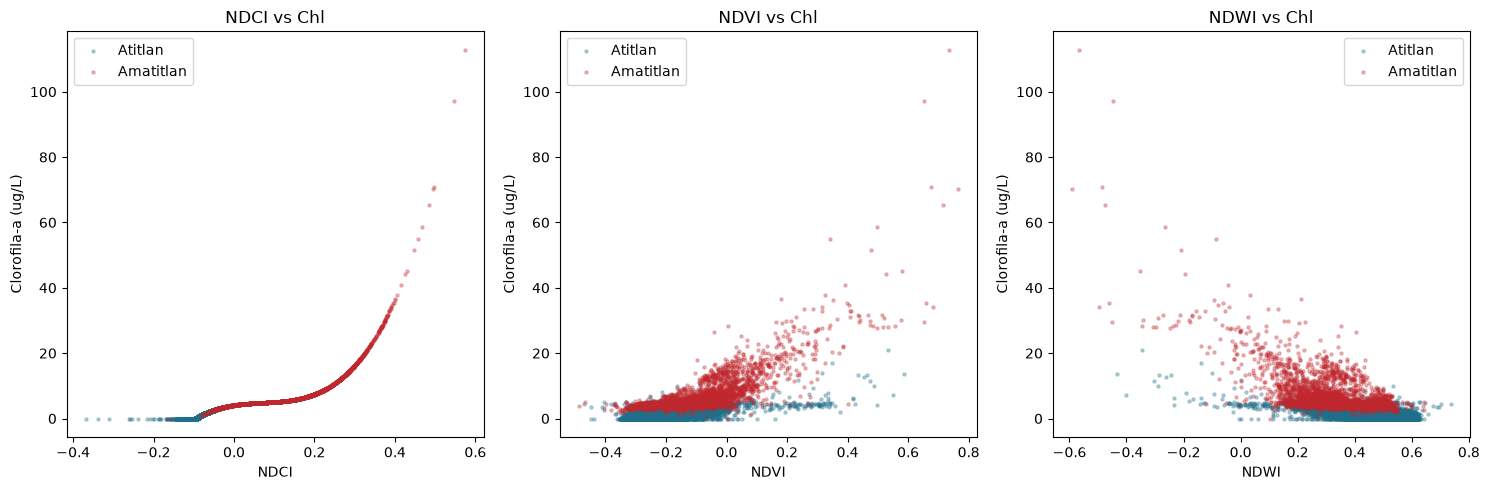

In [12]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var, titulo in zip(ejes, ['ndci', 'ndvi', 'ndwi'], ['NDCI vs Chl', 'NDVI vs Chl', 'NDWI vs Chl']):
    muestra = dataset.sample(min(50000, len(dataset)), random_state=42)
    for lago, color in [('Atitlan', '#1f6f8b'), ('Amatitlan', '#c1272d')]:
        datos_lago = muestra[muestra['lago'] == lago]
        ax.scatter(datos_lago[var], datos_lago['chl'], alpha=0.3, s=5, color=color, label=lago)
    ax.set_xlabel(var.upper())
    ax.set_ylabel('Clorofila-a (ug/L)')
    ax.set_title(titulo)
    ax.legend()

plt.tight_layout()
plt.show()

## 1.6 Decisiones de preparacion y limpieza de datos

### Decisiones tomadas

**1. Unidad de observacion:** Cada fila del dataset es un **pixel individual de agua valida**, no un promedio por lago o por fecha. Esto permite:
- Aprovechar la resolucion espacial de 20 m de Sentinel-2
- Entrenar modelos que predigan a nivel de pixel
- Generar mapas predictivos de alta resolucion

**2. Filtros aplicados:**
- **Mascara de agua:** Se usan solo pixeles clasificados como agua por la funcion `mascara_agua()` del script CyanoLakes. Esto elimina tierra, vegetacion y superficies artificiales.
- **Descarte de nubes:** Se eliminan pixeles con cirrus (B10 > 0.01) o nube densa (B02 y B03 brillantes). Esto garantiza que la reflectancia no esta contaminada por atmosferica.
- **Piso de senal:** Se exigen reflectancias minimas de 0.005 en B04 y B05. Valores menores indican que el cociente NDCI es ruido dividido entre ruido.

**3. Coordenadas en UTM:** Se conservan las coordenadas originales del raster (UTM zona 15N, EPSG:32615) en lugar de convertirlas a WGS84. Esto es consistente con el sistema de referencia usado en los calculos espaciales posteriores (Ejercicio 6).

**4. Almacenamiento en parquet:** El dataset se guarda en formato parquet (`data/derived/dataset_ml.parquet`) para:
- Eficiencia de almacenamiento (~3.7M filas)
- Rapidez de lectura
- Preservacion de tipos de datos

**5. Variables incluidas:**
- **Bandas espectrales:** Las 10 bandas descargadas, en reflectancia (0-1). Son la materia prima para calcular indices.
- **Indices:** NDVI, NDWI, NDCI, FAI. Cada uno captura un aspecto diferente de la firma espectral.
- **Clorofila-a:** Variable respuesta continua (ug/L). Se usara para construir la variable respuesta binaria en el Ejercicio 2.

**6. No se incluyen:**
- Pixeles fuera del agua (tierra, nubes)
- Pixeles con senal insuficiente
- Variables derivadas de la mascara de agua (como `agua_valida`)

### Justificacion

El dataset resultante contiene **3,759,121 observaciones** (3.3M Atitlan, 400K Amatitlan) distribuidas en 22 fechas. Cada observacion tiene 19 variables: coordenadas, metadata (lago, fecha), 10 bandas espectrales, 4 indices y clorofila-a.

Este volumen de datos es adecuado para entrenar modelos de machine learning, permitiendo:
- Division en conjuntos de entrenamiento/prueba
- Validacion cruzada espacial (Ejercicio 6)
- Generalizacion entre lagos (Ejercicio 7)

La ausencia de valores faltantes simplifica el preprocesamiento. Los modelos pueden entrenarse directamente sobre este dataset sin imputacion ni eliminacion adicional de filas.

---

**Siguiente:** `08_Variable_Respuesta.ipynb` — Construccion de la variable respuesta binaria (Ejercicio 2).